# Scaling & Dimensionality Reduction (PCA)
**IT Number:** IT25101195 · **Name:** Perera G.T. D · **Dataset:** `weatherHistory.csv`

## 1. Why this technique is needed
The numeric weather columns sit on very different scales — Humidity ranges roughly 0–1, Pressure sits around 1000, Wind Speed up to ~64. Any distance-based model (KNN, SVM, k-means) or PCA itself would let Pressure dominate purely because of its scale, not because it's more informative. Scaling puts every feature on equal footing first; PCA then checks whether the seven numeric weather columns can be compressed into fewer dimensions without losing much information.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("../../data/raw/weatherHistory.csv")
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [33]:
df["Precip Type"] = df["Precip Type"].fillna("none")

df['target'] = (
    df['Summary'].str.strip().str.lower() == 'clear'
).astype(int)

num_cols = ["Temperature (C)", "Apparent Temperature (C)", "Humidity",
            "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"]
df[num_cols].describe().loc[["mean", "std", "min", "max"]]

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.000000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,1046.380000


## 1. Select Numerical Features

The numerical weather variables are selected for scaling and PCA. `Loud Cover` is excluded because it has zero variance in this dataset, so it cannot contribute useful information to PCA.

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Pressure (millibars)'
]

X = df[pca_features].copy()
print('Features used for Scaling and PCA:')
print(pca_features)
print('\nShape:', X.shape)

Features used for Scaling and PCA:
['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)']

Shape: (96453, 7)


## 2. Feature Scaling using StandardScaler

StandardScaler transforms each feature so that it has approximately **mean = 0** and **standard deviation = 1**. This is important before PCA because PCA is variance-based and otherwise variables with larger numerical scales could dominate the components.

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=pca_features)

print('Scaled feature means:')
print(X_scaled_df.mean().round(3))

print('\nScaled feature standard deviations:')
print(X_scaled_df.std().round(3))

Scaled feature means:
Temperature (C)            -0.0
Apparent Temperature (C)    0.0
Humidity                   -0.0
Wind Speed (km/h)          -0.0
Wind Bearing (degrees)     -0.0
Visibility (km)            -0.0
Pressure (millibars)       -0.0
dtype: float64

Scaled feature standard deviations:
Temperature (C)             1.0
Apparent Temperature (C)    1.0
Humidity                    1.0
Wind Speed (km/h)           1.0
Wind Bearing (degrees)      1.0
Visibility (km)             1.0
Pressure (millibars)        1.0
dtype: float64


## 3. PCA – Explained Variance

PCA is first fitted with all components to determine how much variance each principal component explains. The cumulative explained variance is then used to decide how many dimensions should be retained.

In [36]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (individual, cumulative) in enumerate(
    zip(explained_variance, cumulative_variance), start=1
):
    print(f'PC{i}: {individual * 100:.2f}% | Cumulative: {cumulative * 100:.2f}%')

PC1: 39.41% | Cumulative: 39.41%
PC2: 16.49% | Cumulative: 55.90%
PC3: 14.42% | Cumulative: 70.32%
PC4: 13.50% | Cumulative: 83.82%
PC5: 10.27% | Cumulative: 94.09%
PC6: 5.84% | Cumulative: 99.93%
PC7: 0.07% | Cumulative: 100.00%


In [37]:
pca_2 = PCA(n_components=2)

pca_2.fit(X_scaled)

explained_variance_2 = pca_2.explained_variance_ratio_

cumulative_variance_2 = np.cumsum(explained_variance_2)

for i, (individual, cumulative) in enumerate(
    zip(explained_variance_2, cumulative_variance_2), start=1
):
    print(f"PC{i}: {individual * 100:.2f}% | Cumulative: {cumulative * 100:.2f}%")

PC1: 39.41% | Cumulative: 39.41%
PC2: 16.49% | Cumulative: 55.90%


In [38]:
pca_4 = PCA(n_components=4)

pca_4.fit(X_scaled)

explained_variance_4 = pca_4.explained_variance_ratio_

cumulative_variance_4 = np.cumsum(explained_variance_4)

for i, (individual, cumulative) in enumerate(
    zip(explained_variance_4, cumulative_variance_4), start=1
):
    print(f"PC{i}: {individual * 100:.2f}% | Cumulative: {cumulative * 100:.2f}%")

PC1: 39.41% | Cumulative: 39.41%
PC2: 16.49% | Cumulative: 55.90%
PC3: 14.42% | Cumulative: 70.32%
PC4: 13.50% | Cumulative: 83.82%


In [39]:
pca2 = PCA(n_components=2, random_state=42)
pcs = pca2.fit_transform(X_scaled)
df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]

loadings = pd.DataFrame(pca2.components_.T, columns=["PC1", "PC2"], index=pca_features)
print("Feature loadings on the first 2 components:")
print(loadings.round(3))

Feature loadings on the first 2 components:
                            PC1    PC2
Temperature (C)           0.569 -0.134
Apparent Temperature (C)  0.561 -0.184
Humidity                 -0.480 -0.146
Wind Speed (km/h)         0.068  0.771
Wind Bearing (degrees)    0.032  0.512
Visibility (km)           0.355  0.119
Pressure (millibars)      0.007 -0.239


In [40]:
pca4 = PCA(n_components=4, random_state=42)
pcs = pca4.fit_transform(X_scaled)
df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]
df["PC3"] = pcs[:, 2]
df["PC4"] = pcs[:, 3]

loadings = pd.DataFrame(pca4.components_.T, columns=["PC1", "PC2", "PC3", "PC4"], index=pca_features)
print("Feature loadings on the first 4 components:")
print(loadings.round(3))

Feature loadings on the first 4 components:
                            PC1    PC2    PC3    PC4
Temperature (C)           0.569 -0.134 -0.078  0.110
Apparent Temperature (C)  0.561 -0.184 -0.079  0.149
Humidity                 -0.480 -0.146  0.029  0.207
Wind Speed (km/h)         0.068  0.771  0.062 -0.474
Wind Bearing (degrees)    0.032  0.512  0.244  0.816
Visibility (km)           0.355  0.119  0.237 -0.112
Pressure (millibars)      0.007 -0.239  0.931 -0.139


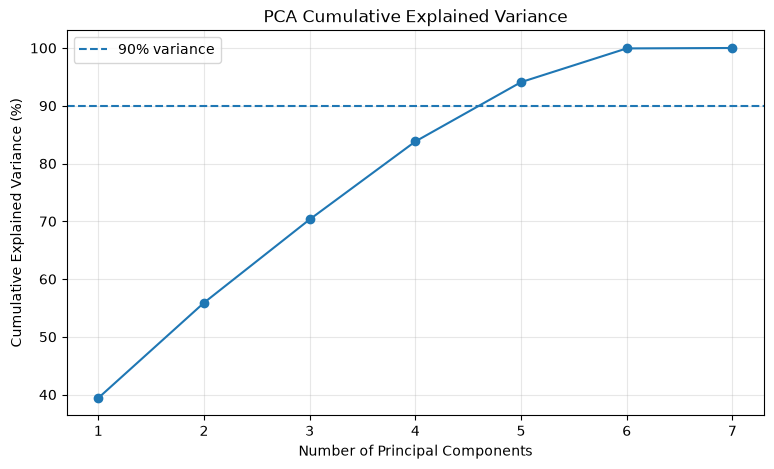

In [41]:
plt.figure(figsize=(9, 5))
components = range(1, len(explained_variance) + 1)
plt.plot(components, cumulative_variance * 100, marker='o')
plt.axhline(90, linestyle='--', label='90% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Cumulative Explained Variance')
plt.xticks(list(components))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

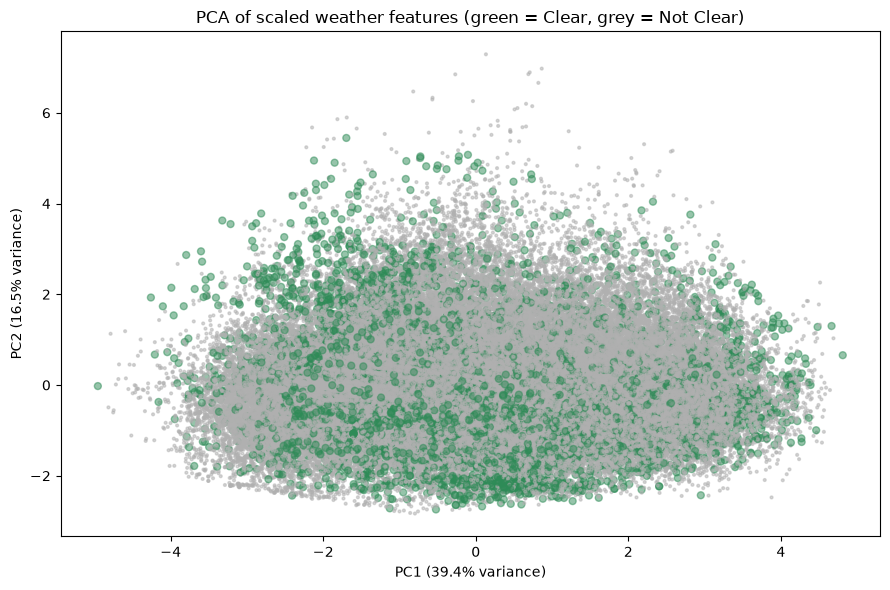

In [43]:
plt.figure(figsize=(9, 6))
colors = df["target"].map({1: "#2E8B57", 0: "#B0B0B0"})
sizes = df["target"].map({1: 25, 0: 4})
plt.scatter(df["PC1"], df["PC2"], c=colors, s=sizes, alpha=0.5)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of scaled weather features (green = Clear, grey = Not Clear)")
plt.tight_layout()
import os
os.makedirs("../results/eda_visualizations", exist_ok=True)
plt.savefig("../results/eda_visualizations/member6_pca_scatter.png", dpi=110)
plt.show()

## 4. Dimensionality Reduction

Five components are retained because they provide at least 90% cumulative explained variance for this dataset. The first two components are also created separately for 2D visualization.

In [44]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print('Components required for at least 90% variance:', n_components_90)

pca_reduced = PCA(n_components=n_components_90)
X_pca = pca_reduced.fit_transform(X_scaled)

pca_columns = [f'PC{i}' for i in range(1, n_components_90 + 1)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=df.index)

print('Reduced data shape:', X_pca_df.shape)
display(X_pca_df.head())

Components required for at least 90% variance: 5
Reduced data shape: (96453, 5)


,PC1,PC2,PC3,PC4,PC5
0,-0.193205,0.781919,0.647591,0.183998,1.261343
1,-0.131097,0.861931,0.668741,0.198861,1.228804
2,-0.282776,-0.637340,0.392006,0.574167,1.392762
3,-0.186826,0.949487,0.709902,0.223026,1.242229
4,-0.138043,0.536315,0.648909,0.376349,1.318760


## 5. PCA Loadings

The loadings show how strongly the original weather features contribute to each principal component.

In [45]:
loadings = pd.DataFrame(
    pca_reduced.components_.T,
    columns=pca_columns,
    index=pca_features
)

display(loadings.round(3))

,PC1,PC2,PC3,PC4,PC5
Temperature (C),0.569,-0.134,-0.078,0.110,-0.189
Apparent Temperature (C),0.561,-0.184,-0.079,0.149,-0.176
Humidity,-0.480,-0.146,0.029,0.207,0.188
Wind Speed (km/h),0.068,0.771,0.062,-0.474,-0.225
Wind Bearing (degrees),0.032,0.512,0.244,0.816,-0.039
Visibility (km),0.355,0.119,0.237,-0.112,0.888
Pressure (millibars),0.007,-0.239,0.931,-0.139,-0.237


## 6. Two-Component PCA Visualization

The first two principal components are used to visualize the high-dimensional weather data in two dimensions. This is mainly for visualization; the reduced dataset above retains the components needed to preserve at least 90% of the variance.

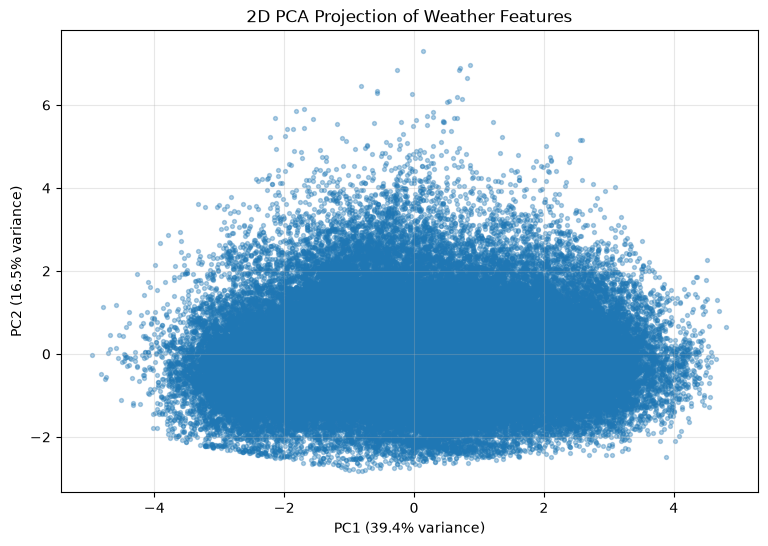

In [46]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.35, s=8)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.title('2D PCA Projection of Weather Features')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Final Scaled and PCA-Reduced Dataset

The scaled features and PCA-reduced representation are saved for later modelling/analysis.

In [48]:
final_pca_df = pd.concat(
    [
        X_scaled_df.add_prefix('Scaled_'),
        X_pca_df
    ],
    axis=1
)

output_path = '../results/outputs/scaling_dimensionality_reduction_output.csv'
final_pca_df.to_csv(output_path, index=False)

final_pca_df.to_csv("../results/outputs/member6_scaled_pca.csv", index=False)

print('Final output shape:', final_pca_df.shape)
print('Saved to:', output_path)


Final output shape: (96453, 12)
Saved to: ../results/outputs/scaling_dimensionality_reduction_output.csv


## Conclusion

StandardScaler successfully puts the selected weather variables on a common scale. PCA then reduces the dimensionality while retaining at least 90% of the variance using the selected number of principal components. The 2D PCA projection is useful for visualization, while the 90%-variance PCA representation is more appropriate when dimensionality reduction is required for further analysis or modelling.